In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
dataset = '/content/drive/MyDrive/archive.zip'

In [4]:
from zipfile import ZipFile
with ZipFile(dataset,'r') as zip:
  zip.extractall('/content/')
  print('The dataset is extracted')

The dataset is extracted


In [5]:
!ls

data  drive  sample_data


In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
from google.colab.patches import cv2_imshow
from PIL import Image
from sklearn.model_selection import train_test_split

In [7]:
with_mask_files = os.listdir('/content/data/with_mask')
print(with_mask_files[:5])
print(with_mask_files[-5:])

['with_mask_68.jpg', 'with_mask_1580.jpg', 'with_mask_634.jpg', 'with_mask_1950.jpg', 'with_mask_2461.jpg']
['with_mask_773.jpg', 'with_mask_2308.jpg', 'with_mask_3495.jpg', 'with_mask_409.jpg', 'with_mask_2346.jpg']


In [8]:
without_mask_files = os.listdir('/content/data/without_mask')
print(without_mask_files[:5])
print(without_mask_files[-5:])

['without_mask_2062.jpg', 'without_mask_2912.jpg', 'without_mask_2564.jpg', 'without_mask_2464.jpg', 'without_mask_2860.jpg']
['without_mask_1615.jpg', 'without_mask_3229.jpg', 'without_mask_3406.jpg', 'without_mask_3090.jpg', 'without_mask_2049.jpg']


In [9]:
print('Number of with Mask images:', len(with_mask_files))
print('Number of without Mask images:', len(without_mask_files))

Number of with Mask images: 3725
Number of without Mask images: 3828


## Creating labels for both classes
with mask: 1

without mask: 0

In [10]:
with_mask_label = [1]*3725
without_mask_label = [0]*3828
print(with_mask_label[:5])
print(without_mask_label[:5])

[1, 1, 1, 1, 1]
[0, 0, 0, 0, 0]


In [11]:
print(len(with_mask_label))
print(len(without_mask_label))

3725
3828


In [12]:
labels = with_mask_label + without_mask_label
print('Total labels are:', len(labels))
print(labels[:5])
print(labels[-5:])

Total labels are: 7553
[1, 1, 1, 1, 1]
[0, 0, 0, 0, 0]


## Displaying images

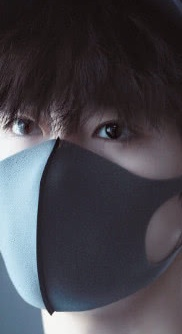

In [13]:
mask_img = cv2.imread('/content/data/with_mask/with_mask_1536.jpg')
cv2_imshow(mask_img)

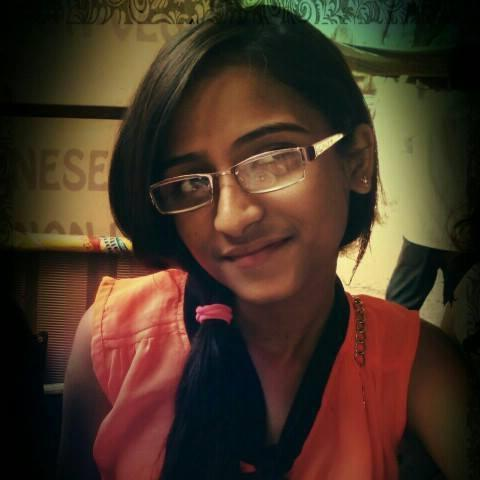

In [14]:
no_mask_img = cv2.imread('/content/data/without_mask/without_mask_1248.jpg')
cv2_imshow(no_mask_img)

## Image preprocessing
1. Resize Images
2. Convert the images to numpy arrays

In [15]:
with_mask_path = '/content/data/with_mask/'

data = []

for img_file in with_mask_files:

  image = Image.open(os.path.join(with_mask_path, img_file))
  image = image.resize((128,128))
  image = image.convert('RGB')
  image = np.array(image)
  data.append(image)



without_mask_path = '/content/data/without_mask/'


for img_file in without_mask_files:

  image = Image.open(os.path.join(without_mask_path, img_file))
  image = image.resize((128,128))
  image = image.convert('RGB')
  image = np.array(image)
  data.append(image)

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


In [16]:
len(data)

7553

array([[[ 37,  30,  22],
        [ 39,  35,  26],
        [ 41,  38,  30],
        ...,
        [ 24,  25,  20],
        [ 23,  23,  21],
        [ 22,  22,  20]],

       [[ 38,  31,  23],
        [ 40,  36,  27],
        [ 42,  39,  31],
        ...,
        [ 24,  25,  20],
        [ 23,  23,  21],
        [ 23,  23,  21]],

       [[ 40,  36,  27],
        [ 42,  38,  29],
        [ 43,  40,  31],
        ...,
        [ 25,  25,  23],
        [ 24,  24,  24],
        [ 24,  24,  24]],

       ...,

       [[205, 143,  70],
        [207, 146,  73],
        [211, 148,  76],
        ...,
        [140,  88,  28],
        [136,  86,  23],
        [133,  83,  20]],

       [[226, 166,  94],
        [228, 167,  95],
        [228, 167,  95],
        ...,
        [140,  88,  28],
        [138,  88,  27],
        [136,  86,  25]],

       [[235, 175, 103],
        [235, 175, 103],
        [234, 174, 101],
        ...,
        [141,  89,  29],
        [138,  88,  27],
        [137,  87,  26]]], dtype=uint8)
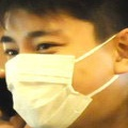

In [17]:
data[0]

In [18]:
data[0].shape

(128, 128, 3)

In [19]:
X = np.array(data)
y = np.array(labels)

In [20]:
print(X.shape)
print(y.shape)

(7553, 128, 128, 3)
(7553,)


In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [22]:
# scaling the data

X_train_scaled = X_train/255

X_test_scaled = X_test/255

In [23]:
X_train_scaled[0]

array([[[0.96862745, 0.98039216, 0.99215686],
        [0.96470588, 0.97647059, 0.98823529],
        [0.96078431, 0.97254902, 0.98823529],
        ...,
        [0.96470588, 0.97647059, 0.98823529],
        [0.96470588, 0.97647059, 0.99215686],
        [0.96470588, 0.97647059, 0.99607843]],

       [[0.90980392, 0.92156863, 0.94117647],
        [0.90980392, 0.92156863, 0.94117647],
        [0.90196078, 0.91372549, 0.93333333],
        ...,
        [0.90588235, 0.91764706, 0.9372549 ],
        [0.90980392, 0.92156863, 0.94117647],
        [0.92156863, 0.93333333, 0.95294118]],

       [[0.9254902 , 0.9372549 , 0.95686275],
        [0.9254902 , 0.9372549 , 0.95686275],
        [0.91764706, 0.92941176, 0.94901961],
        ...,
        [0.92156863, 0.93333333, 0.95294118],
        [0.92156863, 0.93333333, 0.95294118],
        [0.91764706, 0.92941176, 0.94901961]],

       ...,

       [[0.74901961, 0.74509804, 0.74901961],
        [0.56862745, 0.56470588, 0.56862745],
        [0.69803922, 0

In [32]:
import tensorflow as tf
from tensorflow import keras
from keras.callbacks import EarlyStopping, ModelCheckpoint

In [37]:
model1 = keras.Sequential()

model1.add(keras.layers.Conv2D(64, kernel_size=(3,3), activation='relu', input_shape=(128,128,3)))
model1.add(keras.layers.MaxPooling2D(pool_size=(2,2)))


model1.add(keras.layers.Conv2D(32, kernel_size=(3,3), activation='relu'))
model1.add(keras.layers.MaxPooling2D(pool_size=(2,2)))

model1.add(keras.layers.Flatten())

model1.add(keras.layers.Dense(128, activation='relu'))
model1.add(keras.layers.Dropout(0.5))

model1.add(keras.layers.Dense(64, activation='relu'))
model1.add(keras.layers.Dropout(0.5))


model1.add(keras.layers.Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [38]:
# Callbacks
early_stopping = EarlyStopping(monitor='val_loss',
                               patience=4,
                               restore_best_weights= True)

checkpoint = ModelCheckpoint("best_maskmodel.h5",
                             monitor='val_loss',
                             save_best_only= True)

In [39]:
model1.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [40]:
history = model1.fit(X_train_scaled, y_train,
                    validation_split=0.1, epochs=15,
                    callbacks = [early_stopping,checkpoint])

Epoch 1/15
170/170 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7246 - loss: 0.5472

170/170 ━━━━━━━━━━━━━━━━━━━━ 205s 1s/step - accuracy: 0.8089 - loss: 0.4227 - val_accuracy: 0.8810 - val_loss: 0.2786
Epoch 2/15
170/170 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8832 - loss: 0.2789

170/170 ━━━━━━━━━━━━━━━━━━━━ 259s 1s/step - accuracy: 0.8867 - loss: 0.2758 - val_accuracy: 0.9074 - val_loss: 0.2535
Epoch 3/15
170/170 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9137 - loss: 0.2324

170/170 ━━━━━━━━━━━━━━━━━━━━ 205s 1s/step - accuracy: 0.9080 - loss: 0.2409 - val_accuracy: 0.9041 - val_loss: 0.2261
Epoch 4/15
170/170 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9106 - loss: 0.2146

170/170 ━━━━━━━━━━━━━━━━━━━━ 209s 1s/step - accuracy: 0.9132 - loss: 0.2157 - val_accuracy: 0.9240 - val_loss: 0.2053
Epoch 5/15
170/170 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9331 - loss: 0.1843

170/170 ━━━━━━━━━━━━━━━━━━━━ 255s 1s/step - accuracy: 0.9331 - loss: 0.1737 - val_accuracy: 0.9455 - val_loss: 0.1958
Epoch 6/15
170/170 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9483 - loss: 0.1450

170/170 ━━━━━━━━━━━━━━━━━━━━ 203s 1s/step - accuracy: 0.9465 - loss: 0.1456 - val_accuracy: 0.9322 - val_loss: 0.1947
Epoch 7/15
170/170 ━━━━━━━━━━━━━━━━━━━━ 261s 1s/step - accuracy: 0.9518 - loss: 0.1279 - val_accuracy: 0.9421 - val_loss: 0.2360
Epoch 8/15
170/170 ━━━━━━━━━━━━━━━━━━━━ 204s 1s/step - accuracy: 0.9570 - loss: 0.1054 - val_accuracy: 0.9306 - val_loss: 0.2318
Epoch 9/15
170/170 ━━━━━━━━━━━━━━━━━━━━ 200s 1s/step - accuracy: 0.9663 - loss: 0.0886 - val_accuracy: 0.9504 - val_loss: 0.2359
Epoch 10/15
170/170 ━━━━━━━━━━━━━━━━━━━━ 202s 1s/step - accuracy: 0.9715 - loss: 0.0775 - val_accuracy: 0.9421 - val_loss: 0.2600


In [41]:
loss, accuracy = model1.evaluate(X_test_scaled, y_test)
print('Test accuracy: ',accuracy)

48/48 ━━━━━━━━━━━━━━━━━━━━ 15s 310ms/step - accuracy: 0.9040 - loss: 0.2498
Test accuracy:  0.9040370583534241


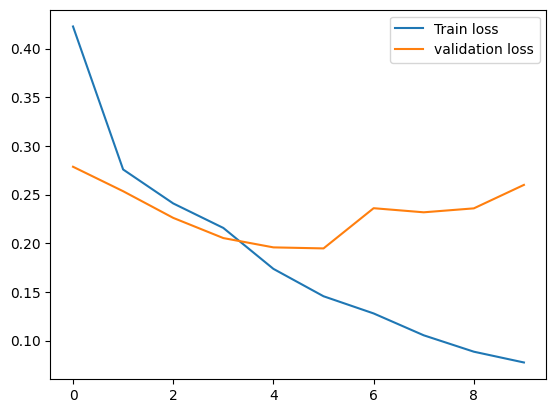

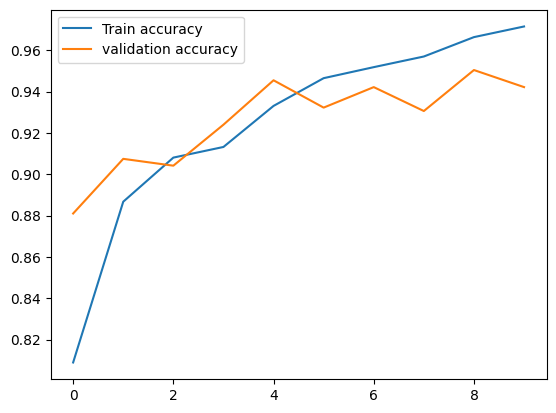

In [42]:
plt.plot(history.history['loss'], label='Train loss')
plt.plot(history.history['val_loss'], label='validation loss')
plt.legend()
plt.show()

plt.plot(history.history['accuracy'], label='Train accuracy')
plt.plot(history.history['val_accuracy'], label='validation accuracy')
plt.legend()
plt.show()

## Prediction system:

Path of the image to be predicted: /content/data/with_mask/with_mask_1236.jpg


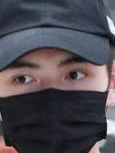

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
[[0.7831127]]
Approved! The person in the image is wearing a mask.


In [82]:
input_image_path = input('Path of the image to be predicted: ')

#for displaying image
input_image = cv2.imread(input_image_path)
cv2_imshow(input_image)

#preprocessing
img = Image.open(input_image_path)
img = img.resize((128,128))
img = img.convert('RGB')

img = np.array(img)/255
img = img.reshape(1,128,128,3)

prediction = model1.predict(img)
print(prediction)

if prediction[0][0] > 0.65:
  print('Approved! The person in the image is wearing a mask.')
else:
  print('Warning! The person in the image is not wearing a mask.')
  print('Please wear a mask!')

Path of the image to be predicted: /content/data/without_mask/without_mask_1545.jpg


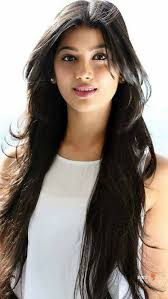

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
[[0.19551332]]
Warning! The person in the image is not wearing a mask.
Please wear a mask!


In [88]:
input_image_path = input('Path of the image to be predicted: ')

#for displaying image
input_image = cv2.imread(input_image_path)
cv2_imshow(input_image)

#preprocessing
img = Image.open(input_image_path)
img = img.resize((128,128))
img = img.convert('RGB')

img = np.array(img)/255
img = img.reshape(1,128,128,3)

prediction = model1.predict(img)
print(prediction)

if prediction[0][0] > 0.65:
  print('Approved! The person in the image is wearing a mask.')
else:
  print('Warning! The person in the image is not wearing a mask.')
  print('Please wear a mask!')